# Week 4 Data Exploration Challenge
## Welltory COVID-19 and Wearables Open Data
### AIPI 510 - Data Sourcing & Analytics  

In [9]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 510

## Load the source tables

In [10]:
BASE_URL = "https://raw.githubusercontent.com/Welltory/hrv-covid19/master/data"
FILES = {
    "participants": "participants.csv",
    "wearables": "wearables.csv",
    "weather": "weather.csv",
    "sleep": "sleep.csv",
    "surveys": "surveys.csv",
}

tables = {name: pd.read_csv(f"{BASE_URL}/{filename}") for name, filename in FILES.items()}

inventory = pd.DataFrame([
    {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "unique_users": df["user_code"].nunique() if "user_code" in df else np.nan,
        "memory_mb": df.memory_usage(deep=True).sum() / 1_000_000,
    }
    for name, df in tables.items()
]).set_index("table")
inventory

,rows,columns,unique_users,memory_mb
table,,,,
participants,185,8,185,0.072
wearables,3098,18,79,0.812
weather,1717,7,104,0.299
sleep,425,12,10,0.149
surveys,2259,5,111,0.695


### What each table contains

| Table | What each row should represent | Columns that identify a row | Important fields |
|---|---|---|---|
| participants | one row per participant | `user_code` | gender, age range, location, height, weight, symptom onset |
| wearables | one row per participant-day | `user_code`, `day` | pulse, SpO2, temperature, steps, distance, calories |
| weather | one row per participant-day | `user_code`, `day` | temperature, pressure, precipitation, humidity, clouds |
| sleep | one row per participant-day | `user_code`, `day` | sleep timing, duration, sleep stages, pulse |
| surveys | one row per participant-date-scale | `user_code`, `created_at`, `scale` | coded result and text interpretation |

The data dictionary describes sleep durations as hours, but the raw values include numbers like 19,881. These are likely seconds as this would be equivalent to about 5.5 hours, so this notebook tests the distribution and converts them to hours.

## Structural profiling and data completeness

The summary below shows each column's data type, missing-value rate, number of different values, and common examples. Completeness is labeled as complete (>99%), mostly complete (95–99%), incomplete (80–95%), or sparse (<80%). A missing sensor value might not always an error as it could mean the person's device did not support that measurement or no measurement was taken.

In [11]:
# Basic profile for the wearable data
wearables = tables["wearables"]
wearable_profile = pd.DataFrame({
    "dtype": wearables.dtypes.astype(str),
    "null_count": wearables.isna().sum(),
    "null_rate": wearables.isna().mean(),
    "distinct_values": wearables.nunique(),
})

wearable_profile["completeness"] = np.select(
    [wearable_profile["null_rate"] < 0.01, wearable_profile["null_rate"] <= 0.05, wearable_profile["null_rate"] <= 0.20],
    ["complete", "mostly complete", "incomplete"],
    default="sparse",
)
wearable_profile = wearable_profile.sort_values("null_rate", ascending=False)
display(wearable_profile)

# The same missing-value summary for sleep data
sleep = tables["sleep"]
sleep_profile = pd.DataFrame({
    "null_count": sleep.isna().sum(),
    "null_rate": sleep.isna().mean(),
    "distinct_values": sleep.nunique(),
}).sort_values("null_rate", ascending=False)
display(sleep_profile)

,dtype,null_count,null_rate,distinct_values,completeness
average_spo2_value,float64,3058,0.987,8,sparse
body_temperature_avg,float64,3033,0.979,20,sparse
average_environment_exposure,float64,2949,0.952,141,sparse
average_headphone_exposure,float64,2868,0.926,226,sparse
stand_hours_total,float64,2567,0.829,19,sparse
active_calories_burned,float64,1898,0.613,660,sparse
total_number_of_flights_climbed,float64,1863,0.601,91,sparse
steps_speed,float64,1680,0.542,1212,sparse
resting_pulse,float64,1583,0.511,66,sparse
distance,float64,1229,0.397,1581,sparse


,null_count,null_rate,distinct_values
sleep_rem_duration,418,0.984,5
sleep_awake_duration,416,0.979,6
sleep_deep_duration,411,0.967,12
pulse_min,410,0.965,11
pulse_max,410,0.965,11
pulse_average,410,0.965,14
sleep_light_duration,398,0.936,22
user_code,0,0.000,10
day,0,0.000,154
sleep_begin,0,0.000,424


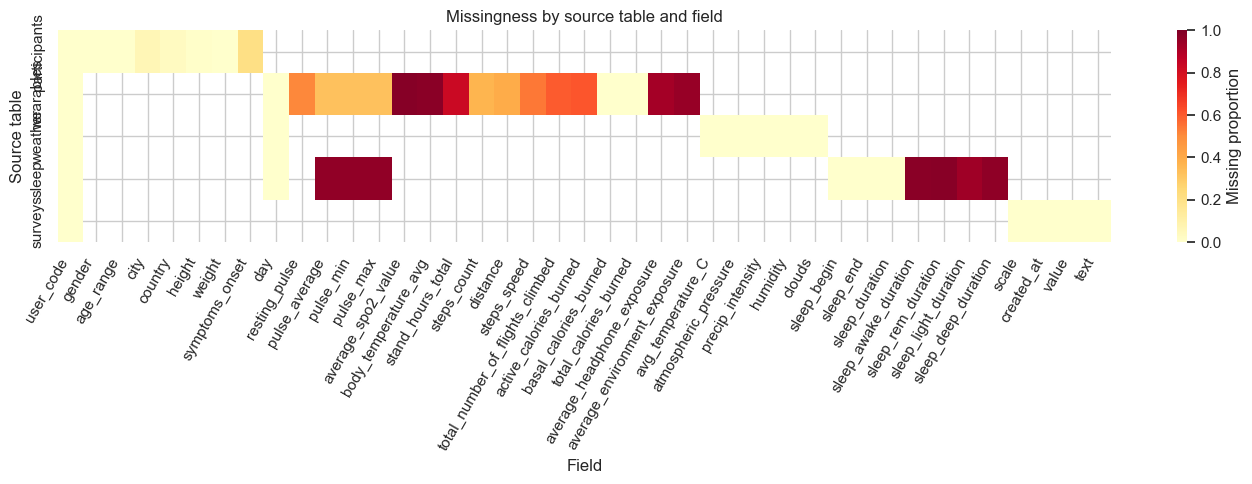

In [12]:
missingness = pd.concat(
    {name: df.isna().mean() for name, df in tables.items()},
    axis=1,
).T

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(missingness, cmap="YlOrRd", vmin=0, vmax=1, ax=ax, cbar_kws={"label": "Missing proportion"})
ax.set_title("Missingness by source table and field")
ax.set_xlabel("Field")
ax.set_ylabel("Source table")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

The sparsest wearable fields are blood oxygen (98.7% missing), body temperature (97.9%), environmental sound exposure (95.2%), and headphone exposure (92.6%). These values were probably not measured because many participants’ devices did not support those features.

In the sleep data, REM sleep, awake time, deep sleep, and light sleep are also mostly missing. Some devices may have recorded total sleep time without recording each sleep stage. Because these values were not measured, replacing them with an average would create data that did not actually exist.

##  Clean types, duplicates, and invalid values

Strategy used:

1. Remove exact duplicate rows because they contain no new information.
2. Parse dates explicitly and report failures.
3. Preserve sensor missingness and create availability indicators.
4. Replace physically impossible and inconsistent values with missing values.
5. Flag outliers flagged by IQR rule.
6. Aggregate duplicate participant-day rows using the median for numeric fields.

In [13]:
clean = {name: df.copy() for name, df in tables.items()}

duplicate_report = []
for name, df in clean.items():
    duplicate_report.append({"table": name, "exact_duplicates": int(df.duplicated().sum())})
    clean[name] = df.drop_duplicates().copy()

date_columns = {
    "participants": ["symptoms_onset"],
    "wearables": ["day"],
    "weather": ["day"],
    "sleep": ["day", "sleep_begin", "sleep_end"],
    "surveys": ["created_at"],
}

parse_report = []
for table_name, columns in date_columns.items():
    for column in columns:
        original_non_null = clean[table_name][column].notna().sum()
        clean[table_name][column] = pd.to_datetime(clean[table_name][column], errors="coerce")
        parsed_non_null = clean[table_name][column].notna().sum()
        parse_report.append({
            "table": table_name,
            "column": column,
            "parse_failures": int(original_non_null - parsed_non_null),
        })

pd.DataFrame(duplicate_report).merge(pd.DataFrame(parse_report), on="table", how="outer")

,table,exact_duplicates,column,parse_failures
0,participants,0,symptoms_onset,0
1,wearables,0,day,0
2,weather,0,day,0
3,sleep,0,day,0
4,sleep,0,sleep_begin,0
5,sleep,0,sleep_end,0
6,surveys,0,created_at,0


In [14]:
# Broad value checks used to catch impossible values, not make medical judgments
bounds = pd.DataFrame([
    ["participants", "height", 80, 250],
    ["participants", "weight", 20, 350],
    ["wearables", "resting_pulse", 25, 250],
    ["wearables", "pulse_average", 25, 250],
    ["wearables", "pulse_min", 25, 250],
    ["wearables", "pulse_max", 25, 250],
    ["wearables", "average_spo2_value", 50, 100],
    ["wearables", "body_temperature_avg", 30, 45],
    ["wearables", "steps_count", 0, 150000],
    ["weather", "humidity", 0, 100],
    ["weather", "clouds", 0, 100],
], columns=["table", "column", "minimum", "maximum"])

# SpO2 is stored as a 0-1 proportion, so convert it to a percentage first
spo2 = pd.to_numeric(clean["wearables"]["average_spo2_value"], errors="coerce")
spo2_fraction = spo2.notna() & spo2.between(0, 1)
clean["wearables"].loc[spo2_fraction, "average_spo2_value"] = spo2.loc[spo2_fraction] * 100

invalid_report = []
for _, rule in bounds.iterrows():
    values = pd.to_numeric(clean[rule["table"]][rule["column"]], errors="coerce")
    invalid = ~values.between(rule["minimum"], rule["maximum"]) & values.notna()
    invalid_report.append({
        "field": f"{rule['table']}.{rule['column']}",
        "invalid_count": int(invalid.sum()),
    })
    clean[rule["table"]].loc[invalid, rule["column"]] = np.nan

pulse_order_invalid = (
    (clean["wearables"]["pulse_min"] > clean["wearables"]["pulse_average"])
    | (clean["wearables"]["pulse_average"] > clean["wearables"]["pulse_max"])
)
invalid_report.append({"field": "pulse minimum <= average <= maximum", "invalid_count": int(pulse_order_invalid.sum())})
clean["wearables"].loc[pulse_order_invalid, ["pulse_min", "pulse_average", "pulse_max"]] = np.nan

# The study took place in 2020. Onset dates far outside the surrounding COVID period are invalid.
onset = clean["participants"]["symptoms_onset"]
implausible_onset = onset.notna() & ~onset.between("2019-12-01", "2020-12-31")
invalid_report.append({"field": "symptom date outside study period", "invalid_count": int(implausible_onset.sum())})
clean["participants"].loc[implausible_onset, "symptoms_onset"] = pd.NaT

pd.DataFrame(invalid_report).set_index("field")

,invalid_count
field,
participants.height,0
participants.weight,0
wearables.resting_pulse,0
wearables.pulse_average,0
wearables.pulse_min,3
wearables.pulse_max,0
wearables.average_spo2_value,0
wearables.body_temperature_avg,0
wearables.steps_count,0


In [15]:
# Check the documented sleep-duration unit against observed values, then convert seconds to hours.
sleep_duration_fields = [
    "sleep_duration", "sleep_awake_duration", "sleep_rem_duration",
    "sleep_light_duration", "sleep_deep_duration",
]
sleep_raw_summary = clean["sleep"][sleep_duration_fields].describe().T[["count", "50%", "max"]]
display(sleep_raw_summary)

for column in sleep_duration_fields:
    clean["sleep"][f"{column}_hours"] = pd.to_numeric(clean["sleep"][column], errors="coerce") / 3600

clean["sleep"]["time_in_bed_hours"] = (
    clean["sleep"]["sleep_end"] - clean["sleep"]["sleep_begin"]
).dt.total_seconds() / 3600

clean["sleep"][["sleep_duration_hours", "time_in_bed_hours"]].describe().T

,count,50%,max
sleep_duration,425.000,"26,041.000","47,460.000"
sleep_awake_duration,9.000,"2,490.000","4,200.000"
sleep_rem_duration,7.000,"6,240.000","8,730.000"
sleep_light_duration,27.000,"17,340.000","23,100.000"
sleep_deep_duration,14.000,"4,230.000","7,934.000"


,count,mean,std,min,25%,50%,75%,max
sleep_duration_hours,425.000,7.139,2.159,0.258,6.071,7.234,8.500,13.183
time_in_bed_hours,425.000,7.139,2.159,0.258,6.071,7.234,8.500,13.183


As mentioned earlier these values in the tens of thousands could not reasonably represent hours but do represent typical sleep durations in seconds. Therefore we derive an `_hours` field that divides the raw values by 3,600. 

## Create the participant-day analysis table

Each daily table is reduced to one row per person and day. If a person has more than one record on the same day, numeric values are combined using the median because it is less affected by extreme values. Participant details, weather, sleep, and the ordered COVID symptom score are then joined to the wearable table.

In [16]:
# Combine repeated daily records using the median
wearable_numbers = clean["wearables"].select_dtypes(include="number").columns.tolist()
wearables_daily = clean["wearables"].groupby(["user_code", "day"], as_index=False)[wearable_numbers].median()

weather_numbers = clean["weather"].select_dtypes(include="number").columns.tolist()
weather_daily = clean["weather"].groupby(["user_code", "day"], as_index=False)[weather_numbers].median()

sleep_hour_columns = [f"{column}_hours" for column in sleep_duration_fields] + ["time_in_bed_hours"]
sleep_daily = clean["sleep"].groupby(["user_code", "day"], as_index=False)[sleep_hour_columns].median()

covid_overall = (
    clean["surveys"].loc[clean["surveys"]["scale"].eq("S_COVID_OVERALL")]
    .assign(value=lambda df: pd.to_numeric(df["value"], errors="coerce"))
    .groupby(["user_code", "created_at"], as_index=False)["value"].median()
    .rename(columns={"created_at": "day", "value": "covid_overall_severity"})
)

participants_unique = clean["participants"].drop_duplicates("user_code", keep="first")
analysis = (
    wearables_daily
    .merge(participants_unique, on="user_code", how="left", validate="many_to_one")
    .merge(weather_daily, on=["user_code", "day"], how="left", validate="one_to_one", suffixes=("", "_weather"))
    .merge(sleep_daily, on=["user_code", "day"], how="left", validate="one_to_one")
    .merge(covid_overall, on=["user_code", "day"], how="left", validate="one_to_one")
)

analysis["days_from_symptom_onset"] = (analysis["day"] - analysis["symptoms_onset"]).dt.days
analysis["bmi"] = analysis["weight"] / (analysis["height"] / 100) ** 2
analysis["has_sleep_data"] = analysis["sleep_duration_hours"].notna()
analysis["has_weather_data"] = analysis["avg_temperature_C"].notna()
analysis["log_steps"] = np.log1p(analysis["steps_count"])
analysis["weekend"] = analysis["day"].dt.dayofweek >= 5

analysis.head()

,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure,gender,age_range,city,country,height,weight,symptoms_onset,avg_temperature_C,atmospheric_pressure,precip_intensity,humidity,clouds,sleep_duration_hours,sleep_awake_duration_hours,sleep_rem_duration_hours,sleep_light_duration_hours,sleep_deep_duration_hours,time_in_bed_hours,covid_overall_severity,days_from_symptom_onset,bmi,has_sleep_data,has_weather_data,log_steps,weekend
0,007b8190cf,2020-04-26,NaN,70.000,70.000,70.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,859.000","2,859.000",NaN,NaN,m,25-34,Mandalay,Myanmar,170.180,96.162,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33.204,False,False,NaN,True
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"8,574.000",NaN,57.900,NaN,NaN,"2,624.000","2,624.000",NaN,NaN,m,45-54,St Petersburg,Russia,178.000,92.000,2020-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-53.000,29.037,False,False,9.057,False
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"7,462.000",NaN,59.100,NaN,NaN,"2,624.000","2,624.000",NaN,NaN,m,45-54,St Petersburg,Russia,178.000,92.000,2020-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-52.000,29.037,False,False,8.918,False
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"2,507.000",NaN,60.970,NaN,NaN,"2,624.000","2,624.000",NaN,NaN,m,45-54,St Petersburg,Russia,178.000,92.000,2020-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-50.000,29.037,False,False,7.827,True
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10,131.000",NaN,49.100,NaN,NaN,"2,624.000","2,624.000",NaN,NaN,m,45-54,St Petersburg,Russia,178.000,92.000,2020-04-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-49.000,29.037,False,False,9.223,True


### Feature-engineering rationale

The primary new feature addition is `days_from_symptom_onset`, which aligns participant's daily observations to their own illness timeline instead of comparing calendar dates. Negative values represent pre-onset days, zero is the reported onset date, and positive values are post-onset days.

Additional features include BMI, sensor-availability flags, weekend status, and `log_steps`. The log transform reduces the visual influence of the long right tail in daily steps while retaining zero-step days.

In [17]:
# Referential integrity and join-coverage assessment
source_user_sets = {name: set(df["user_code"].dropna()) for name, df in clean.items()}
participant_users = source_user_sets["participants"]
integrity = pd.DataFrame([
    {
        "table": name,
        "unique_users": len(users),
        "users_missing_from_participants": len(users - participant_users),
    }
    for name, users in source_user_sets.items()
]).set_index("table")

join_coverage = pd.Series({
    "participant_match_rate": analysis["age_range"].notna().mean(),
    "weather_match_rate": analysis["has_weather_data"].mean(),
    "sleep_match_rate": analysis["has_sleep_data"].mean(),
    "covid_survey_match_rate": analysis["covid_overall_severity"].notna().mean(),
}, name="match_rate")

display(integrity)
display(join_coverage.to_frame())
print(f"Analysis table: {len(analysis):,} participant-days across {analysis['user_code'].nunique():,} participants")
print(f"Date range: {analysis['day'].min().date()} to {analysis['day'].max().date()}")

,unique_users,users_missing_from_participants
table,,
participants,185,0
wearables,79,0
weather,104,0
sleep,10,0
surveys,111,0


,match_rate
participant_match_rate,1.000
weather_match_rate,0.347
sleep_match_rate,0.117
covid_survey_match_rate,0.045


Analysis table: 3,098 participant-days across 79 participants
Date range: 2020-01-01 to 2020-06-19


## Descriptive statistics and outliers

Using IQR rule to identify unusually low or high observations relative to our sample.

In [19]:
metrics = [
    "steps_count", "resting_pulse", "pulse_average", "average_spo2_value",
    "body_temperature_avg", "total_calories_burned", "sleep_duration_hours",
    "avg_temperature_C", "humidity", "bmi", "days_from_symptom_onset",
]
metrics = [column for column in metrics if column in analysis.columns]
display(analysis[metrics].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)

# Use the IQR rule to count possible outliers in each numeric field
outlier_rows = []
for column in metrics:
    values = analysis[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    possible_outliers = ~values.between(lower, upper)
    outlier_rows.append({
        "metric": column,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(possible_outliers.sum()),
        "outlier_rate": possible_outliers.mean(),
    })

outlier_summary = pd.DataFrame(outlier_rows).set_index("metric")
outlier_summary.sort_values("outlier_rate", ascending=False)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
steps_count,"1,968.000","5,342.068","4,761.775",1.000,16.000,75.350,"1,456.000","4,477.500","7,857.250","14,296.200","20,457.270","30,882.000"
resting_pulse,"1,515.000",61.409,12.775,40.000,43.000,46.000,52.000,58.000,69.000,87.300,97.000,109.000
pulse_average,"2,088.000",78.090,14.368,48.000,52.870,58.000,69.000,76.000,85.000,106.000,119.260,163.000
average_spo2_value,40.000,96.100,2.134,92.000,92.000,92.950,94.750,96.000,98.000,99.000,99.000,99.000
body_temperature_avg,65.000,36.405,0.239,35.800,35.928,36.000,36.200,36.400,36.600,36.800,36.836,36.900
total_calories_burned,"3,097.000","2,549.049",804.622,81.000,"1,683.000","1,792.000","2,001.000","2,353.000","2,668.000","4,350.400","5,355.800","8,418.000"
sleep_duration_hours,362.000,7.142,2.172,0.258,0.990,3.470,6.074,7.228,8.496,10.333,11.406,13.183
avg_temperature_C,"1,075.000",11.536,7.441,-8.178,-3.755,0.048,6.522,11.061,15.906,24.798,30.034,40.422
humidity,"1,075.000",66.108,18.635,3.000,12.740,36.500,54.000,67.000,80.167,93.000,100.000,100.000
bmi,"3,098.000",27.911,7.202,16.609,16.609,17.207,22.676,27.465,32.596,39.783,54.277,54.277


,lower_bound,upper_bound,outlier_count,outlier_rate
metric,,,,
total_calories_burned,"1,000.500","3,668.500",324,0.105
sleep_duration_hours,2.442,12.128,15,0.041
pulse_average,45.000,109.000,67,0.032
steps_count,"-8,145.875","17,459.125",44,0.022
resting_pulse,26.500,94.500,27,0.018
bmi,7.795,47.477,51,0.016
humidity,14.750,119.417,15,0.014
avg_temperature_C,-7.553,29.981,13,0.012
days_from_symptom_onset,-126.000,138.000,4,0.002


## Visual exploration

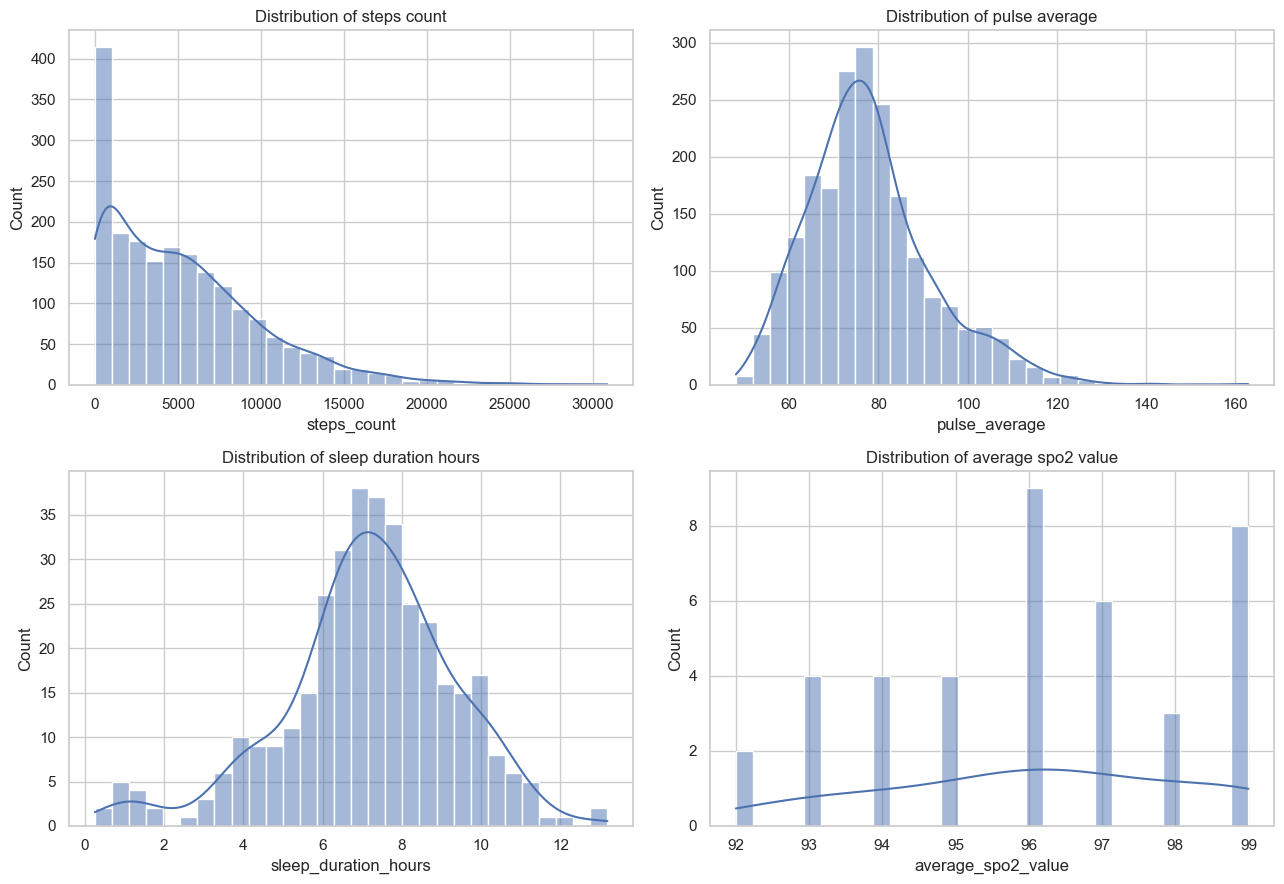

In [20]:
plot_metrics = [column for column in ["steps_count", "pulse_average", "sleep_duration_hours", "average_spo2_value"] if analysis[column].notna().any()]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, column in zip(axes.flat, plot_metrics):
    sns.histplot(data=analysis, x=column, bins=30, kde=True, ax=ax)
    ax.set_title(f"Distribution of {column.replace('_', ' ')}")
for ax in axes.flat[len(plot_metrics):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

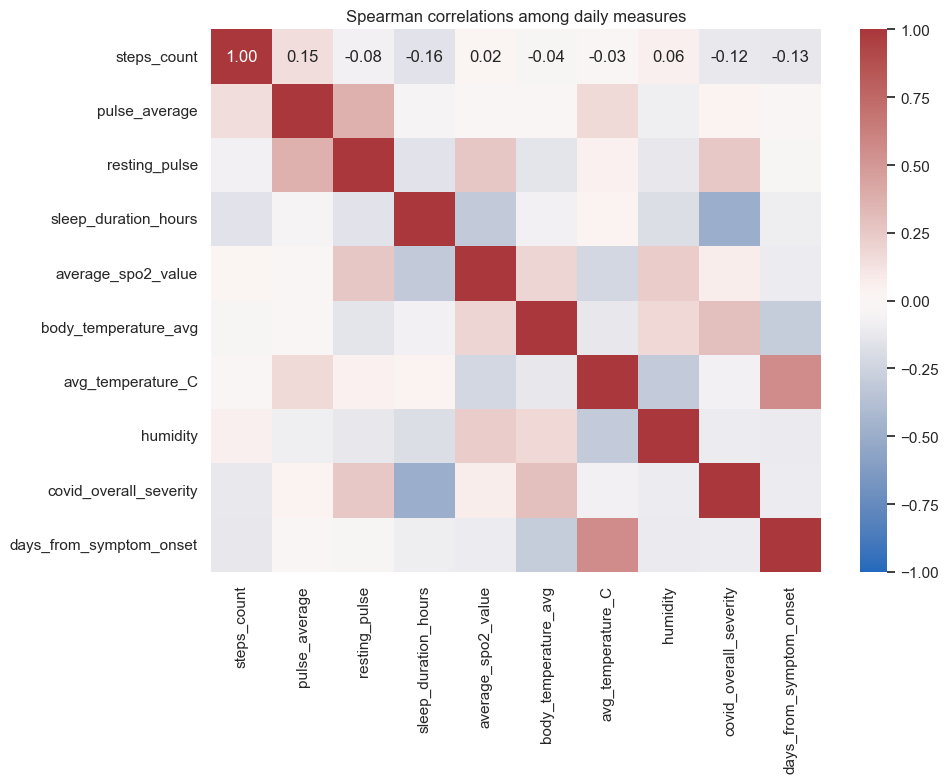

In [22]:
correlation_columns = [
    "steps_count", "pulse_average", "resting_pulse", "sleep_duration_hours",
    "average_spo2_value", "body_temperature_avg", "avg_temperature_C",
    "humidity", "covid_overall_severity", "days_from_symptom_onset",
]
correlation_columns = [c for c in correlation_columns if c in analysis and analysis[c].notna().sum() >= 3]
correlations = analysis[correlation_columns].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(correlations, cmap="vlag", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title("Spearman correlations among daily measures")
plt.tight_layout()
plt.show()

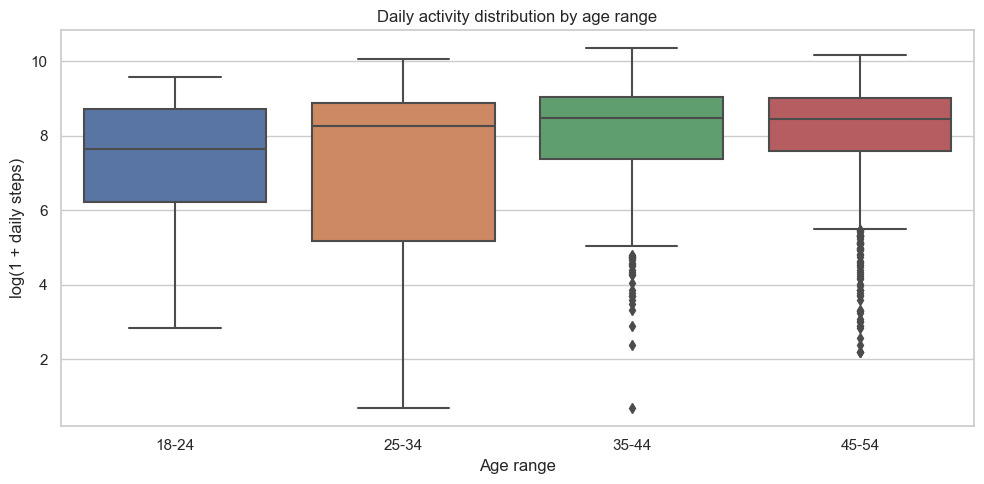

,unique_participants
age_range,
18-24,4.000
25-34,26.000
35-44,21.000
45-54,25.000
55-64,2.000


In [23]:
age_order = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]
age_counts = analysis.groupby("age_range")["user_code"].nunique().reindex(age_order).dropna()
eligible_ages = age_counts[age_counts >= 3].index
age_plot_data = analysis.loc[analysis["age_range"].isin(eligible_ages) & analysis["steps_count"].notna()].copy()

plt.figure(figsize=(10, 5))
sns.boxplot(data=age_plot_data, x="age_range", y="log_steps", order=[x for x in age_order if x in eligible_ages])
plt.title("Daily activity distribution by age range")
plt.xlabel("Age range")
plt.ylabel("log(1 + daily steps)")
plt.tight_layout()
plt.show()
display(age_counts.rename("unique_participants").to_frame())

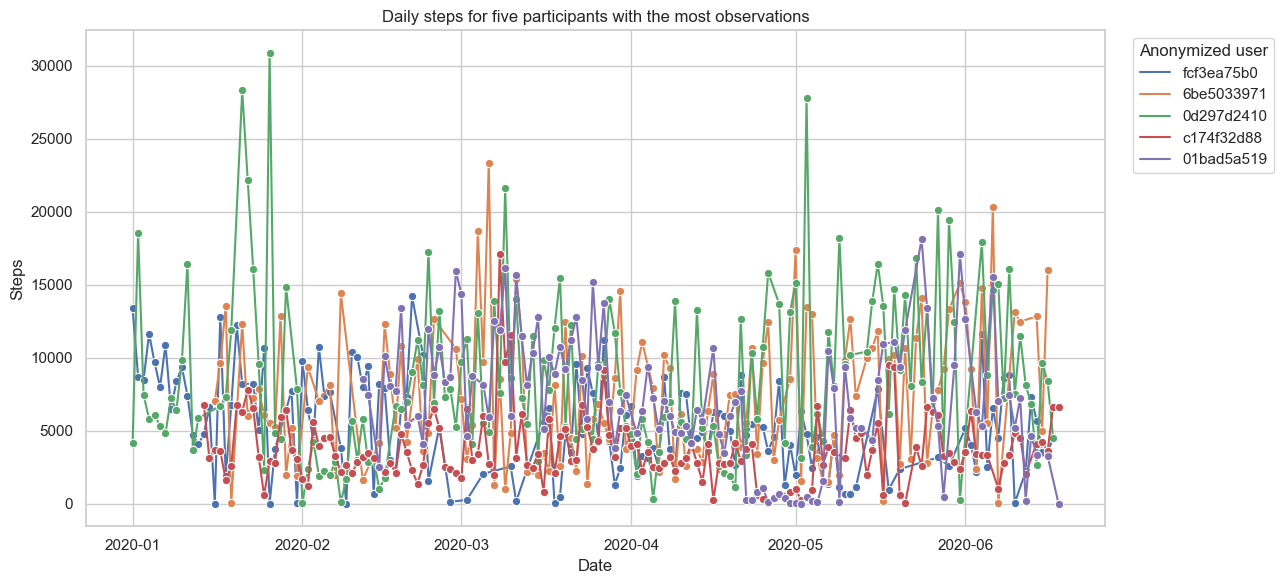

In [24]:
# Illustrative within-person trajectories for participants with the most step observations.
top_users = analysis.groupby("user_code")["steps_count"].count().nlargest(5).index
trajectory = analysis.loc[analysis["user_code"].isin(top_users)].sort_values("day")

plt.figure(figsize=(13, 6))
sns.lineplot(data=trajectory, x="day", y="steps_count", hue="user_code", marker="o", estimator=None)
plt.title("Daily steps for five participants with the most observations")
plt.xlabel("Date")
plt.ylabel("Steps")
plt.legend(title="Anonymized user", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

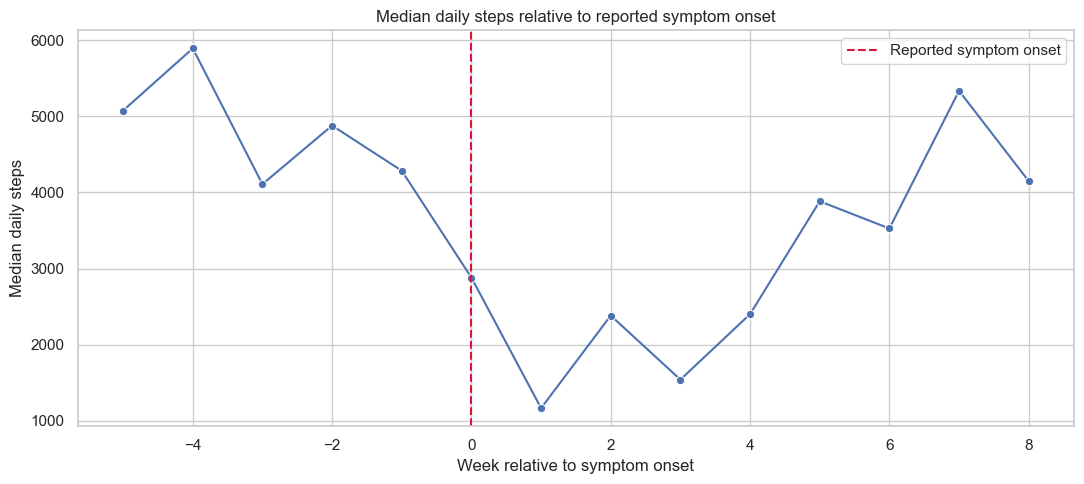

,onset_week,median,count
0,-5,"5,076.000",14
1,-4,"5,893.000",65
2,-3,"4,109.000",73
3,-2,"4,879.000",65
4,-1,"4,285.000",71
5,0,"2,881.000",80
6,1,"1,165.000",82
7,2,"2,382.000",100
8,3,"1,540.500",92
9,4,"2,401.000",86


In [25]:
symptom_plot_data = analysis.dropna(subset=["days_from_symptom_onset", "steps_count"]).copy()
symptom_plot_data = symptom_plot_data.loc[symptom_plot_data["days_from_symptom_onset"].between(-30, 60)]
symptom_plot_data["onset_week"] = np.floor(symptom_plot_data["days_from_symptom_onset"] / 7).astype(int)
weekly_steps = symptom_plot_data.groupby("onset_week")["steps_count"].agg(["median", "count"]).reset_index()
weekly_steps = weekly_steps.loc[weekly_steps["count"] >= 5]

plt.figure(figsize=(11, 5))
sns.lineplot(data=weekly_steps, x="onset_week", y="median", marker="o")
plt.axvline(0, color="crimson", linestyle="--", label="Reported symptom onset")
plt.title("Median daily steps relative to reported symptom onset")
plt.xlabel("Week relative to symptom onset")
plt.ylabel("Median daily steps")
plt.legend()
plt.tight_layout()
plt.show()
weekly_steps

## Key findings

1. **Data Coverage:** The table contains **3,098 participant-days** from **79 participants**, covering January 1 through June 19, 2020. Wearable SpO2 and body-temperature measurements were especially sparse (only 40 and 65 valid participant-days). 
2. **Distributions:** Daily steps were right-skewed. The median was **4,477.5 steps**, compared with a mean of **5,342.1**, and the 99th percentile was **20,457.3**. A log transformation was used for the age-group boxplot as a result.
3. **Relationships:** The largest displayed correlation was **0.562** between outdoor temperature and days from symptom onset. Both values change as the calendar moves forward, so time may explain this result rather than health. Average pulse and resting pulse had a clearer positive relationship of **0.368**. 
4. **Symptom-aligned feature:** Median steps declined from **4,285** in the week before reported onset to **2,881** during onset week and **1,165** in the following week, before varying during later weeks. The displayed window contained **1,012 participant-days** with step and onset information. This pattern may reflect illness.
5. **Quality conclusion:** The dataset is useful for finding patterns and forming questions. However, the participants chose to take part, sensor data is often missing, dates were self-reported, devices differ, and there is no representative comparison group. For those reasons, the data cannot support strong claims about the full population.